In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as base_model
from lr_model import LinearRegressor 
from sklearn.metrics import root_mean_squared_error, r2_score

In [43]:
df = pd.read_csv('../../datasets/Housing.csv', lineterminator='\n')

In [44]:
# selection of features and labels
X = df[['area', 'bedrooms', 'bathrooms', 'stories']]
y= df[['price']]

In [45]:
#preprocessor for scaling columns
preprocessor= ColumnTransformer(
    transformers= [
        ('scaler', StandardScaler(), list(X.columns))
    ],
    remainder= 'passthrough'
)

In [46]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 1243)

In [47]:
#scaling features and adding bias column
X_train= preprocessor.fit_transform(X_train)
X_train = np.c_[X_train, np.ones(X_train.shape[0])]

In [48]:
# scaling hosue prices for training
ss= StandardScaler()
y_train = ss.fit_transform(y_train)

In [49]:
#training
lr= 0.001
epochs= 50_000

model= LinearRegressor(lr)
model.fit(X_train, y_train, epochs)
W = model.get_weights()

In [50]:
# transformation for testing
X_test = preprocessor.transform(X_test)
X_test= np.c_[X_test, np.ones(X_test.shape[0])]

y_test = ss.transform(y_test)

In [51]:
#testing
y_pred = model.predict(X_test).flatten()

In [52]:
# evaluation
rmse = root_mean_squared_error(y_test.flatten(), y_pred)
r2= r2_score(y_test.flatten(), y_pred)

print(f'RMSE error: {rmse:.2f}')
print(f'R2-Score: {r2:.2f}')

RMSE error: 0.69
R2-Score: 0.51


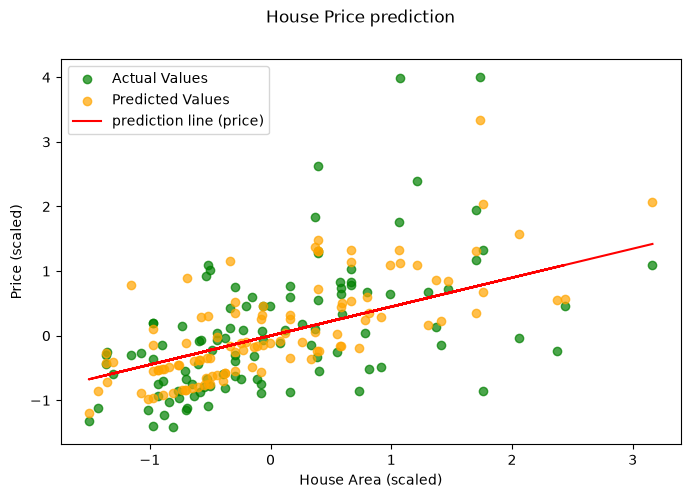

In [65]:
#plotting predicted versus actual values
x_plot= X_test[:, 0]
y_line_val= np.dot(x_plot, W[0]) 

fig= plt.figure(figsize= (8, 5))
fig.suptitle('House Price prediction')
plt.scatter(x= x_plot, y= y_test.flatten(), c= 'green', alpha= 0.7, label= 'Actual Values')
plt.scatter(x= x_plot, y= y_pred.flatten(), c= 'orange', alpha= 0.7, label= 'Predicted Values')
plt.plot(x_plot, y_line_val, color= 'red', label= 'prediction line (price)')

plt.xlabel('House Area (scaled)')
plt.ylabel('Price (scaled)')
plt.legend()
plt.show()

In [ ]:
#plotting errors
cost_hist= model.get_cost_hist()


[np.float64(0.5),
 np.float64(0.49136240717097984),
 np.float64(0.4830172039880353),
 np.float64(0.4749541807600891),
 np.float64(0.4671634900389871),
 np.float64(0.4596356336613555),
 np.float64(0.4523614502559511),
 np.float64(0.4453321031997463),
 np.float64(0.43853906900659445),
 np.float64(0.4319741261329044),
 np.float64(0.4256293441853125),
 np.float64(0.419497073515882),
 np.float64(0.4135699351908832),
 np.float64(0.40784081131970756),
 np.float64(0.4023028357309539),
 np.float64(0.39694938498319415),
 np.float64(0.39177406969837475),
 np.float64(0.3867707262062412),
 np.float64(0.3819334084885983),
 np.float64(0.377256380412615),
 np.float64(0.3727341082427748),
 np.float64(0.3683612534214475),
 np.float64(0.3641326656084181),
 np.float64(0.36004337597005737),
 np.float64(0.3560885907091544),
 np.float64(0.35226368482675463),
 np.float64(0.34856419610765876),
 np.float64(0.3449858193215383),
 np.float64(0.3415244006319149),
 np.float64(0.3381759322055262),
 np.float64(0.33493

## Comparing with a Baseline model

In [ ]:
base_lr= base_model()
base_lr.fit(X_train, y_train)

y_pred_baseline= base_lr.predict(X_test).flatten()

In [ ]:
# evaluation
rmse = root_mean_squared_error(y_test.flatten(), y_pred_baseline)
r2= r2_score(y_test.flatten(), y_pred_baseline)

print(f'RMSE error: {rmse:.2f}')
print(f'R2-Score: {r2:.2f}')

RMSE error: 0.69
R2-Score: 0.51
